### 統計學習與深度學習 (Fall, 2024)
### Homework 3

請將IPYNB檔與IPYNB Export之HTML檔上傳至COOL作業區。作業自己做。嚴禁抄襲。不接受紙本繳交，不接受遲交。請以英文或中文作答。
如無其他規定，所有重要結果應顯示至小數點第四位(四捨五入)。


### 第一題 [Resnet as a Feature Extractor]

(30%) Resnet是一個常用的CNN影像分類的架構。許多深度學習平台，如Pytorch，提供已經在ImageNet資料集上訓練好的模型(i.e., 權重)。這些模型可以直接用來取代傳統的特徵工程。我們在本題與下一期要來嘗試與比較這個方向。

為了方便討論，我們使用Resnet50。當然同樣的作法可以用在其他類似的模型上。

Resnet50的模型架構大致上是

```
ResNet(
  (conv1):

   .... [omitted] ...

  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=2048, out_features=1000, bias=True)
)

```
我們忽略前面的所有層，只專注在最後一層。是一個線性層。輸入是2048維，輸出是1000維。因此如果要把訓練好的Resnet50當成是Feature Extractor，我們可以直些使用模型的最後輸出(尚未進入Softmax)的1000維向量，或是使用前一層的輸出，也就是2048維向量。本題將嘗試使用最後的1000維向量來代表一張圖片。下一題將使用前一層的輸出的2048維向量代表圖片。

請以Pytorch提供的預訓練模型(`torchvision.models.resnet50(weights="IMAGENET1K_V2")`)作為起點往下發展。

為了控制不同的分類器可能會帶來的影響。我們選用Logistic Regression作為最後圖片分類的分類器。也就是說每張在訓練集的圖片都通過同一個Pre-trained Resnet50，轉換成一個1000維的向量。然後訓練一個Logistic Regression做圖片分類。接下來把每一張測試資料通過同一個Pre-trained Resnet50轉換成1000維的向量。使用訓練好的Logistic Regression預測分類，並計算分類效能。

這裡的圖片分類任務我們選用Food101資料集。這個資料集有101類食物的照片。任務是看照片分類食物。

為了節省大家的資料整備時間，我們提供`food101_hwds.tgz`檔案。請下載並存放置工作目錄，並執行`tar zxvf food101_hwds.tgz ./`。你會在工作目錄看到一個food101目錄，下有一個food-101目錄，接下來是`images  license_agreement.txt  meta  README.txt`等檔案。

如果你的資料檔已經正確下載，就可以連上Data Loader:


In [1]:
import torch
import torchvision
from torchvision import models, transforms, datasets

imagenet_stats = [(0.485, 0.456, 0.406), (0.229, 0.224, 0.225)]
        
valid_tfms = transforms.Compose([
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_stats[0], imagenet_stats[1])])     

batch_size = 196
trainset = torchvision.datasets.Food101(root='./food101', split="train",
                                        download=False, transform=valid_tfms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=6)

validset = torchvision.datasets.Food101(root='./food101', split="test",
                                       download=False, transform=valid_tfms)
validloader = torch.utils.data.DataLoader(validset, batch_size=batch_size,
                                         shuffle=False, num_workers=6)

assert trainset.classes==validset.classes
classes = trainset.classes
classe2idx = trainset.class_to_idx
num_classes = len(classes)

print("Number of classes =", num_classes)

Number of classes = 101


這裡有101個分類。列出前幾個給大家參考:

In [2]:
print(trainset.classes[0:10])

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


為了給大家更具體的想法，下面是一些訓練集的照片與分類:

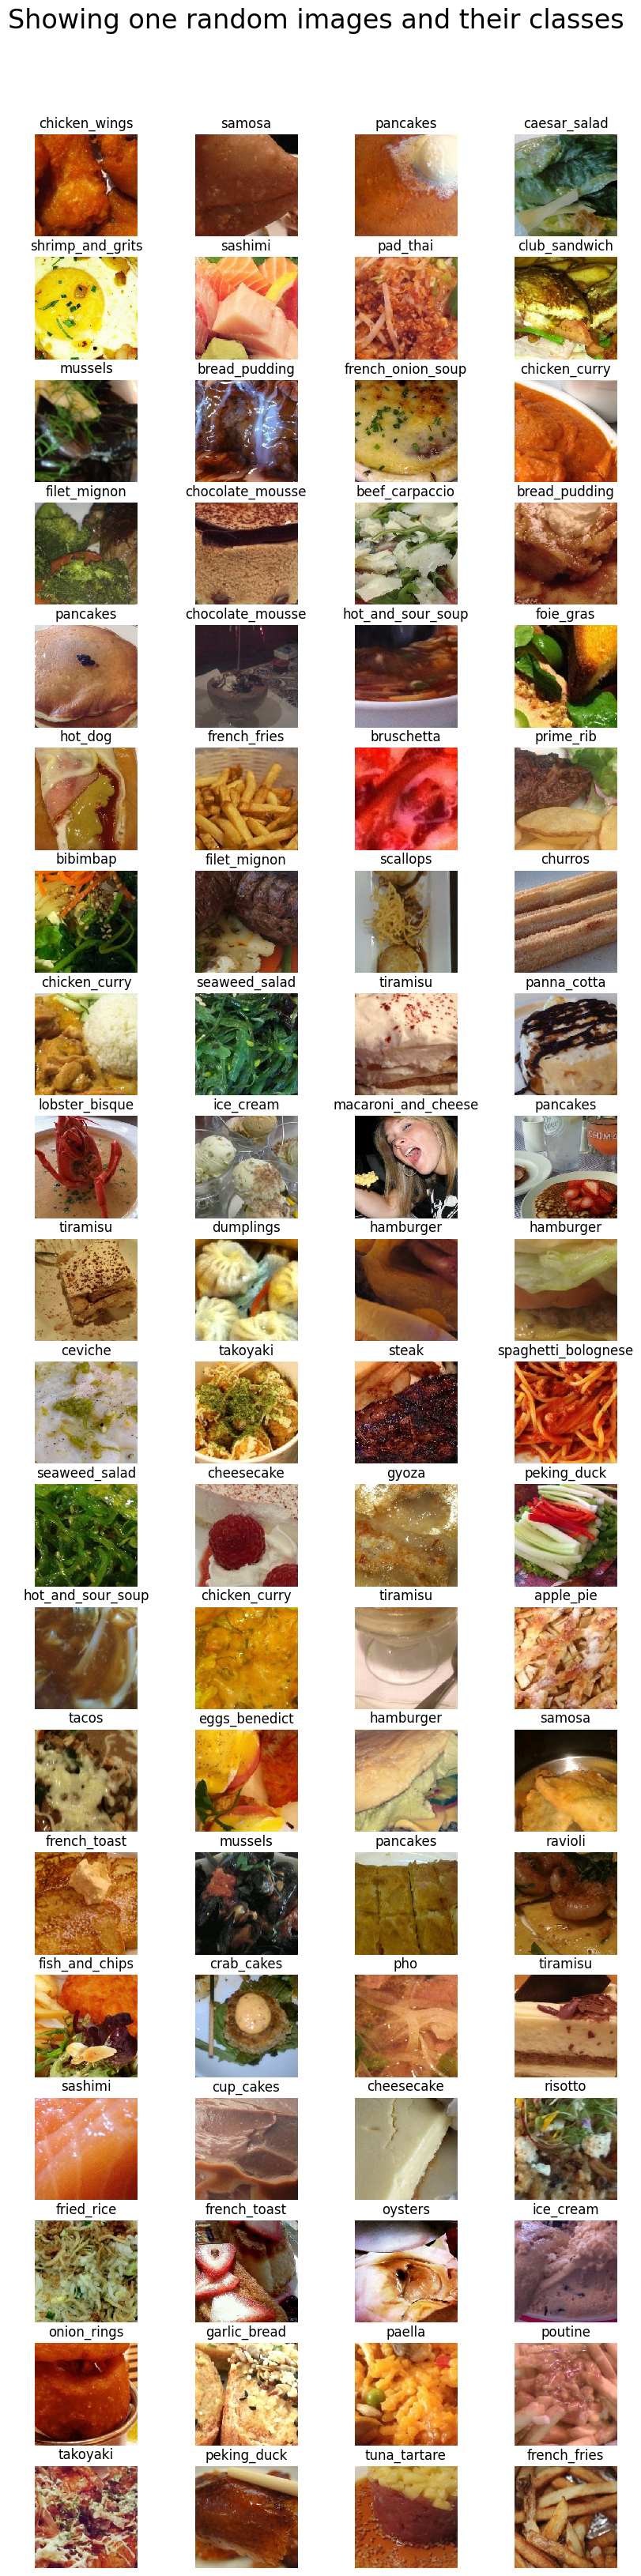

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10,40))
fig.suptitle(f"Showing one random images and their classes", y=0.92, fontsize=24)
columns = 4
rows = 20
imgenet_mean = imagenet_stats[0]
imgenet_std = imagenet_stats[1] 

targetset = trainset
for i in range(1, columns*rows+1):
    fig.add_subplot(rows, columns, i)
    
    img_xy = np.random.randint(len(targetset));
    np_img = targetset[img_xy][0].numpy()
    img = np.transpose(np_img, (1,2,0))
    img = img * imgenet_std + imgenet_mean
    
    plt.title(classes[targetset[img_xy][1]])
    plt.axis('off')
    img = np.clip(img, 0, 1)
    plt.imshow(img, interpolation='nearest')

plt.show()

注意:
1. 由於訓練集較大，請隨機在訓練集選取20000張照片訓練Logistic Regression。
2. 請不要調整測試集(Validation Set)
3. 本題主要的分類效能指標為Accuracy與Macro-average F1

In [52]:
import torch
import torchvision
from torchvision import models, transforms, datasets 
from torch.utils.data import Subset
from torch import nn , optim
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import accuracy_score


In [48]:
# 檢查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [49]:
imagenet_stats = [(0.485, 0.456, 0.406), (0.229, 0.224, 0.225)]
valid_tfms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_stats[0], imagenet_stats[1])
])

batch_size = 196
trainset = torchvision.datasets.Food101(root='./food101', split="train",
                                        download=False, transform=valid_tfms)
validset = torchvision.datasets.Food101(root='./food101', split="test",
                                       download=False, transform=valid_tfms)

# 隨機選取 20,000 張訓練圖片
indices = np.random.choice(len(trainset), 20000, replace=False)
subset_trainset = Subset(trainset, indices)
trainloader = torch.utils.data.DataLoader(subset_trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=6)
validloader = torch.utils.data.DataLoader(validset, batch_size=batch_size,
                                         shuffle=False, num_workers=6)


In [27]:
resnet50 = torchvision.models.resnet50(weights="IMAGENET1K_V2")
feature_extractor = resnet50#torch.nn.Sequential(*list(resnet50.children())[:-1])
feature_extractor = feature_extractor.to(device)



In [34]:
def extract_features(loader):
    feature_extractor.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            output = feature_extractor(images)
            output = output.cpu()  # 將輸出移回 CPU
            features.append(output.view(output.size(0), -1))
            labels.append(target)
    return torch.cat(features), torch.cat(labels)

train_features, train_labels = extract_features(trainloader)
test_features, test_labels = extract_features(validloader)


In [38]:
train_features.shape

torch.Size([20000, 1000])

In [35]:

classifier = LogisticRegression(max_iter=1000,n_jobs=-1)
classifier.fit(train_features, train_labels)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [39]:

test_predictions = classifier.predict(test_features)
accuracy = accuracy_score(test_labels, test_predictions)
macro_f1 = f1_score(test_labels, test_predictions, average='macro')

print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Macro-average F1: {macro_f1*100:.2f}%')


Test Accuracy: 51.88%
Macro-average F1: 51.85%


----

### 第二題 [Resnet as a Feature Extractor, Part 2]

(20%) 呈上題，使用最後fc輸入的2048維作為特徵。訓練Logistic Regression，並計算分類績效。注意事項與前一題一樣。比較這兩種作法的結果。你覺得應該使用2048維或1000為作為特徵向量?

In [40]:
resnet50 = torchvision.models.resnet50(weights="IMAGENET1K_V2")
resnet50.fc = nn.Identity()
feature_extractor = resnet50#torch.nn.Sequential(*list(resnet50.children())[:-1])
feature_extractor = feature_extractor.to(device)




------



In [42]:
def extract_features(loader):
    feature_extractor.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            output = feature_extractor(images)
            output = output.cpu()  # 將輸出移回 CPU
            features.append(output.view(output.size(0), -1))
            labels.append(target)
    return torch.cat(features), torch.cat(labels)

train_features, train_labels = extract_features(trainloader)
test_features, test_labels = extract_features(validloader)


In [43]:

classifier = LogisticRegression(max_iter=1000,n_jobs=-1)
classifier.fit(train_features, train_labels)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [44]:

test_predictions = classifier.predict(test_features)
accuracy = accuracy_score(test_labels, test_predictions)
macro_f1 = f1_score(test_labels, test_predictions, average='macro')

print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Macro-average F1: {macro_f1:.2f}')


Test Accuracy: 55.01%
Macro-average F1: 0.55


### 第三題 [Resnet Finetuning]

(50%) 接下來我們來嘗試一般的Fine-tuning作法。這個作法是以Pre-trained Resnet50做為起點，將最後一層(fc)換成適合這個分類任務的維度，也就是2048 --> 101的線性層，然後進行模型的Fine-tuning (i.e., training)。

這裡通常有兩種作法，一是在Back Propogation時調整所有的權重，二是只調整最後的fc層。請嘗試並比較這兩者的差別。

注意事項:
* 影像前處理在訓練階段與測試階段不同。訓練階段需要有RandomResizedCrop()與RandomHorizontalFlip()。測試階段則只需CenterCrop()。所有階段都需標準化。
* 訓練時請使用Early Stopping。Patient ＝ 5 epochs。最多訓練100 epochs
* 請使用全部訓練集與測試集。
* 本題主要的分類效能指標為Accuracy與Macro-average F1
* 請提供training loss, validation loss, validation accuracy, validation macro f1在訓練期間的線圖。
* 為了簡化問題。我們以訓練期間最佳的validation performance作為模型的一般性預測力指標。



# 準備數據集

------


In [45]:
def plot_metrics(training_losses, validation_losses, validation_accuracies, validation_f1s):
    epochs = range(1, len(training_losses) + 1)
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, training_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, validation_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, validation_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, validation_f1s, label='Validation Macro F1')
    plt.xlabel('Epochs')
    plt.ylabel('Macro F1')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [50]:
 
# 準備數據集
imagenet_stats = [(0.485, 0.456, 0.406), (0.229, 0.224, 0.225)]
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_stats[0], imagenet_stats[1])
])
test_tfms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_stats[0], imagenet_stats[1])
])

batch_size = 64
trainset = datasets.Food101(root='./food101', split="train", download=False, transform=train_tfms)
validset = datasets.Food101(root='./food101', split="test", download=False, transform=test_tfms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=6)
validloader = torch.utils.data.DataLoader(validset, batch_size=batch_size, shuffle=False, num_workers=6)

In [53]:
# 構建模型
resnet = models.resnet50(weights="IMAGENET1K_V2")
resnet.fc = nn.Linear(resnet.fc.in_features, 101)
resnet = resnet.to(device)

# 定義損失函數和優化器
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=0.01)

In [54]:
# 訓練模型
def train_model(model, trainloader, validloader, loss_func, optimizer, epochs=100, patience=5):
    best_loss = float('inf')
    patience_counter = 0
    training_losses = []
    validation_losses = []
    validation_accuracies = []
    validation_f1s = []

    for epoch in range(epochs):
        model.train()
        epoch_training_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_training_loss += loss.item()
        
        training_losses.append(epoch_training_loss / len(trainloader))

        model.eval()
        epoch_validation_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_func(outputs, labels)
                epoch_validation_loss += loss.item()
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        validation_losses.append(epoch_validation_loss / len(validloader))
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        validation_accuracies.append(accuracy)
        validation_f1s.append(f1)

        print(f'Epoch {epoch+1}/{epochs}, Training Loss: {training_losses[-1]:.4f}, Validation Loss: {validation_losses[-1]:.4f}, Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}')

        if epoch_validation_loss < best_loss:
            best_loss = epoch_validation_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    return training_losses, validation_losses, validation_accuracies, validation_f1s

training_losses, validation_losses, validation_accuracies, validation_f1s = train_model(resnet, trainloader, validloader, loss_func, optimizer)

Epoch 1/100, Training Loss: 3.6089, Validation Loss: 2.3721, Accuracy: 0.4478, F1 Score: 0.4316
Epoch 2/100, Training Loss: 1.9912, Validation Loss: 1.6053, Accuracy: 0.5973, F1 Score: 0.5926
Epoch 3/100, Training Loss: 1.5673, Validation Loss: 1.3768, Accuracy: 0.6436, F1 Score: 0.6394
Epoch 4/100, Training Loss: 1.3646, Validation Loss: 1.2374, Accuracy: 0.6725, F1 Score: 0.6696
Epoch 5/100, Training Loss: 1.2440, Validation Loss: 1.1342, Accuracy: 0.6974, F1 Score: 0.6943
Epoch 6/100, Training Loss: 1.1536, Validation Loss: 1.0868, Accuracy: 0.7063, F1 Score: 0.7046
Epoch 7/100, Training Loss: 1.0811, Validation Loss: 1.0422, Accuracy: 0.7206, F1 Score: 0.7188
Epoch 8/100, Training Loss: 1.0297, Validation Loss: 1.0021, Accuracy: 0.7306, F1 Score: 0.7279
Epoch 9/100, Training Loss: 0.9813, Validation Loss: 0.9483, Accuracy: 0.7435, F1 Score: 0.7416
Epoch 10/100, Training Loss: 0.9428, Validation Loss: 0.9285, Accuracy: 0.7500, F1 Score: 0.7486
Epoch 11/100, Training Loss: 0.9036, Va

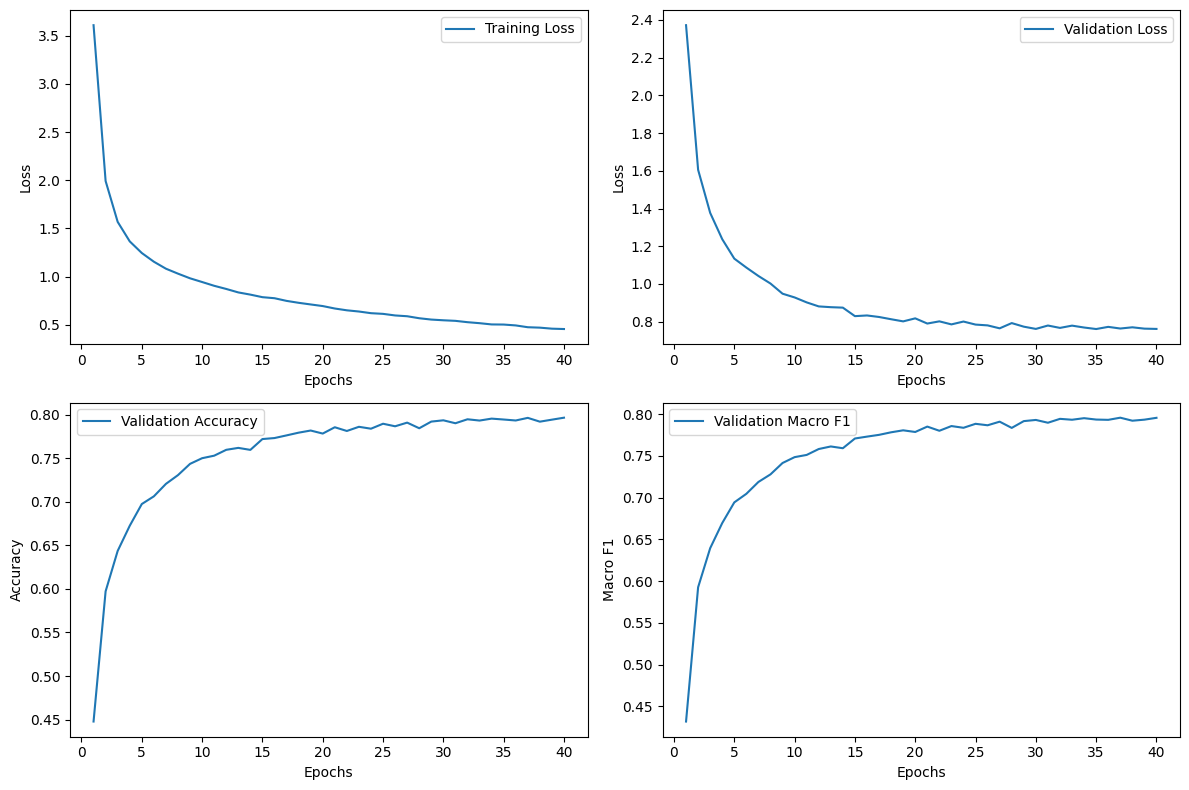

In [57]:

plot_metrics(training_losses, validation_losses, validation_accuracies, validation_f1s)


In [56]:
import pickle

# Save the metrics to a file
metrics = {
    'training_losses': training_losses,
    'validation_losses': validation_losses,
    'validation_accuracies': validation_accuracies,
    'validation_f1s': validation_f1s
}

with open('Back_Propogation.pkl', 'wb') as f:
    pickle.dump(metrics, f)


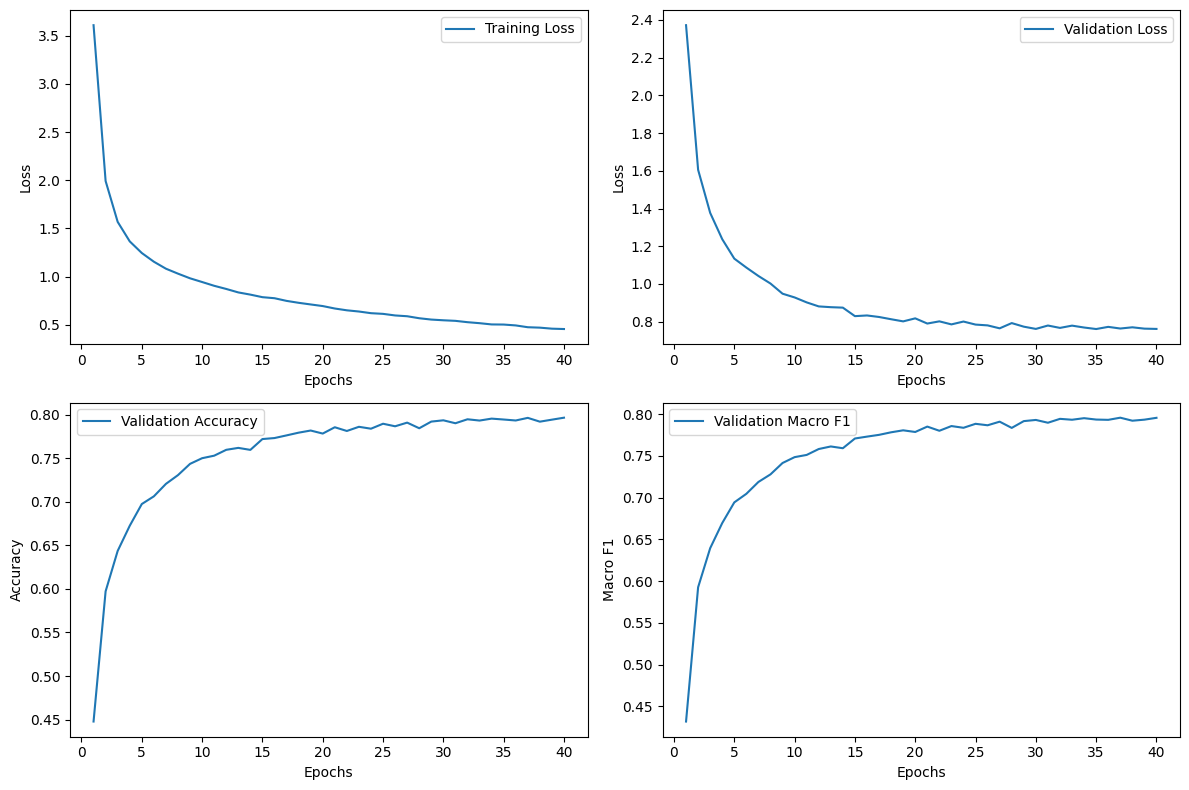

In [59]:
 

# Load the metrics from a file
with open('Back_Propogation.pkl', 'rb') as f:
    metrics = pickle.load(f)

training_losses = metrics['training_losses']
validation_losses = metrics['validation_losses']
validation_accuracies = metrics['validation_accuracies']
validation_f1s = metrics['validation_f1s']

plot_metrics(training_losses, validation_losses, validation_accuracies, validation_f1s)


In [ ]:
# 構建模型
resnet = models.resnet50(weights="IMAGENET1K_V2")
resnet.fc = nn.Linear(resnet.fc.in_features, 101)
resnet = resnet.to(device)

# 冻结所有层的参数
for param in resnet.parameters():
    param.requires_grad = False

# 只训练最后一层
for param in resnet.fc.parameters():
    param.requires_grad = True

# 定義損失函數和優化器
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.fc.parameters(), lr=0.01)

# 訓練模型
training_losses, validation_losses, validation_accuracies, validation_f1s = train_model(resnet, trainloader, validloader, loss_func, optimizer)


Epoch 1/100, Training Loss: 4.3374, Validation Loss: 4.0995, Accuracy: 0.2728, F1 Score: 0.2387
Epoch 2/100, Training Loss: 3.8630, Validation Loss: 3.7023, Accuracy: 0.3255, F1 Score: 0.2901
Epoch 3/100, Training Loss: 3.5142, Validation Loss: 3.4480, Accuracy: 0.3472, F1 Score: 0.3156


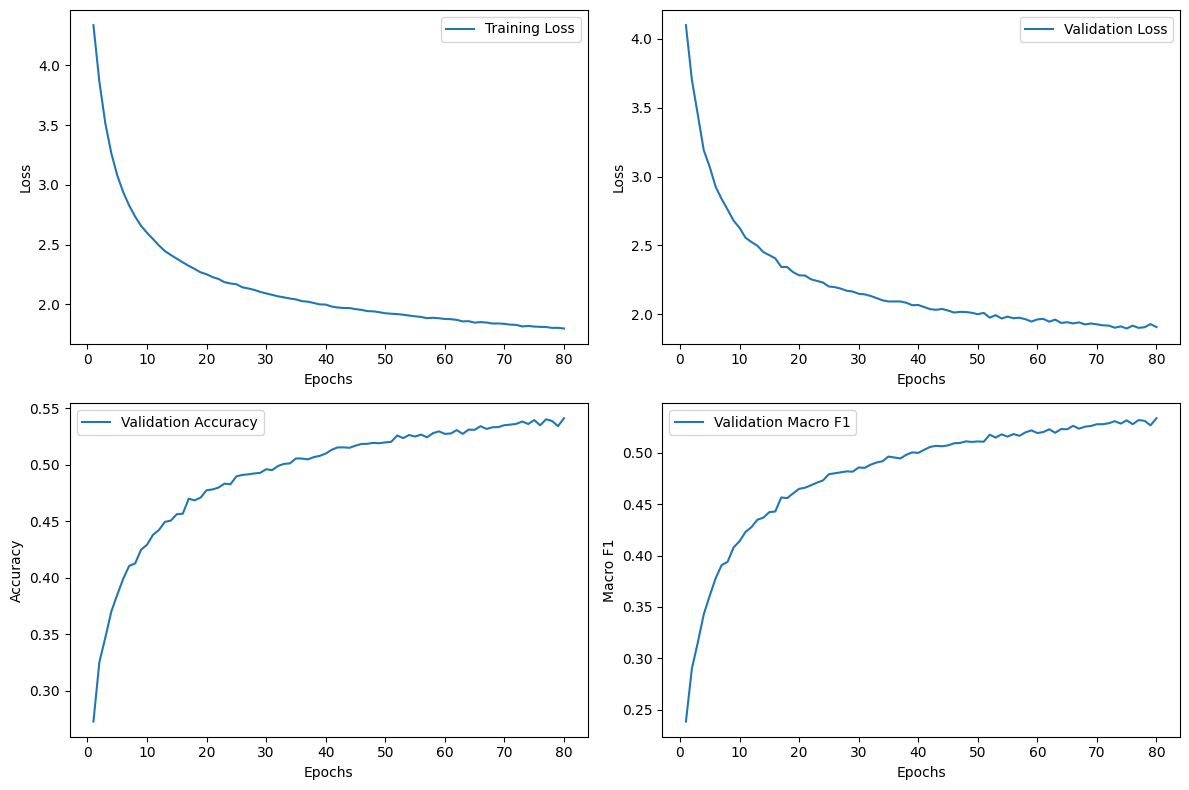

In [61]:
plot_metrics(training_losses, validation_losses, validation_accuracies, validation_f1s)


In [1]:
import pickle

# Save the metrics to a file
metrics = {
    'training_losses': training_losses,
    'validation_losses': validation_losses,
    'validation_accuracies': validation_accuracies,
    'validation_f1s': validation_f1s
}

with open('FC.pkl', 'wb') as f:
    pickle.dump(metrics, f)
plot_metrics(training_losses, validation_losses, validation_accuracies, validation_f1s)


NameError: name 'training_losses' is not defined